In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv(r'group_20.csv')
print(df.shape)
print(df.head())

(1885, 14)
   ID      Age   Gender  Education  Country  Ethnicity   Nscore   Escore  \
0   1  0.49788  0.48246   -0.05921  0.96082    0.12600  0.31287 -0.57545   
1   2 -0.07854 -0.48246    1.98437  0.96082   -0.31685 -0.67825  1.93886   
2   3  0.49788 -0.48246   -0.05921  0.96082   -0.31685 -0.46725  0.80523   
3   4 -0.95197  0.48246    1.16365  0.96082   -0.31685 -0.14882 -0.80615   
4   5  0.49788  0.48246    1.98437  0.96082   -0.31685  0.73545 -1.63340   

    Oscore   Ascore   Cscore  Impulsive       SS Amyl  
0 -0.58331 -0.91699 -0.00665   -0.21712 -1.18084  CL0  
1  1.43533  0.76096 -0.14277   -0.71126 -0.21575  CL2  
2 -0.84732 -1.62090 -1.01450   -1.37983  0.40148  CL0  
3 -0.01928  0.59042  0.58489   -1.37983 -1.18084  CL0  
4 -0.45174 -0.30172  1.30612   -0.21712 -0.21575  CL1  


In [4]:
df['Gender'] = (df['Gender']>0).astype(int)
print(df['Gender'].value_counts())

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])
df['Ethnicity'] = le.fit_transform(df['Ethnicity'])
print(df['Country'].value_counts())
print(df['Ethnicity'].value_counts())

Gender
0    943
1    942
Name: count, dtype: int64
Country
6    1044
0     557
2     118
5      87
3      54
4      20
1       5
Name: count, dtype: int64
Ethnicity
2    1720
4      63
0      33
1      26
5      20
3      20
6       3
Name: count, dtype: int64


In [5]:
def change_classes(cl):
    if cl == 'CL0':
        return 0
    elif cl == 'CL1':
        return 1
    else :
        return 2
df['Amyl'] = df['Amyl'].apply(change_classes)
print(df['Amyl'].value_counts().sort_index())

Amyl
0    1305
1     210
2     370
Name: count, dtype: int64


In [6]:
df['Country_raw'] = df['Country']
df['Ethnicity_raw'] = df['Ethnicity']
scaler = StandardScaler()
cols_to_scale = ['Age', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print(df.head())

   ID       Age  Gender  Education   Country  Ethnicity    Nscore    Escore  \
0   1  0.527566       1  -0.058331  0.812966   4.996609  0.313500 -0.576912   
1   2 -0.128854       0   2.093200  0.812966  -0.113867 -0.679764  1.944499   
2   3  0.527566       0  -0.058331  0.812966  -0.113867 -0.468308  0.807667   
3   4 -1.123504       1   1.229126  0.812966  -0.113867 -0.149189 -0.808263   
4   5  0.527566       1   2.093200  0.812966  -0.113867  0.736994 -1.637850   

     Oscore    Ascore    Cscore  Impulsive        SS  Amyl  Country_raw  \
0 -0.585137 -0.919341 -0.006281  -0.235108 -1.222226     0            6   
1  1.441683  0.763361 -0.142775  -0.752976 -0.220519     2            6   
2 -0.850217 -1.625245 -1.016902  -1.453650  0.420129     0            6   
3 -0.018822  0.592338  0.586885  -1.453650 -1.222226     0            6   
4 -0.453034 -0.302329  1.310098  -0.235108 -0.220519     1            6   

   Ethnicity_raw  
0              5  
1              2  
2              2 

In [7]:
df.to_csv(r'group_20_1.csv', index=False)

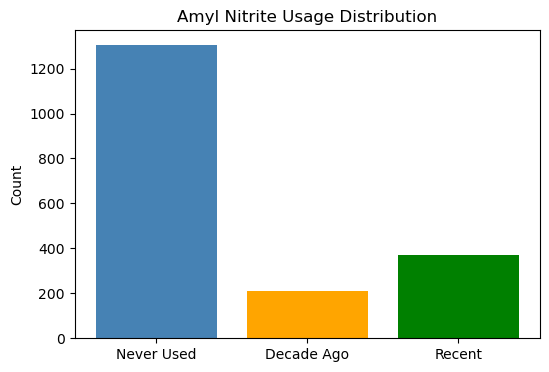

In [8]:
plt.figure(figsize=(6,4))
counts = df['Amyl'].value_counts().sort_index()
plt.bar(['Never Used', 'Decade Ago', 'Recent'], counts, color=['steelblue', 'orange', 'green'])
plt.title('Amyl Nitrite Usage Distribution')
plt.ylabel('Count')
plt.show()

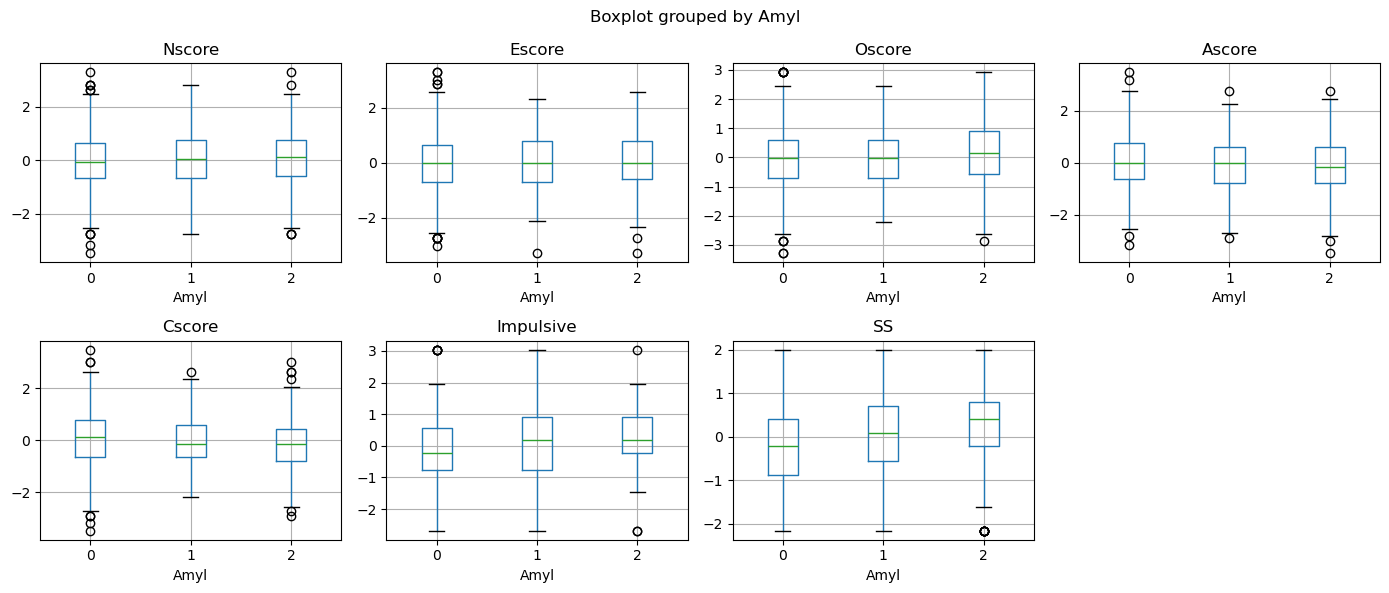

In [9]:
personality = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(personality):
    df.boxplot(column=col, by='Amyl', ax=axes[i])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()  

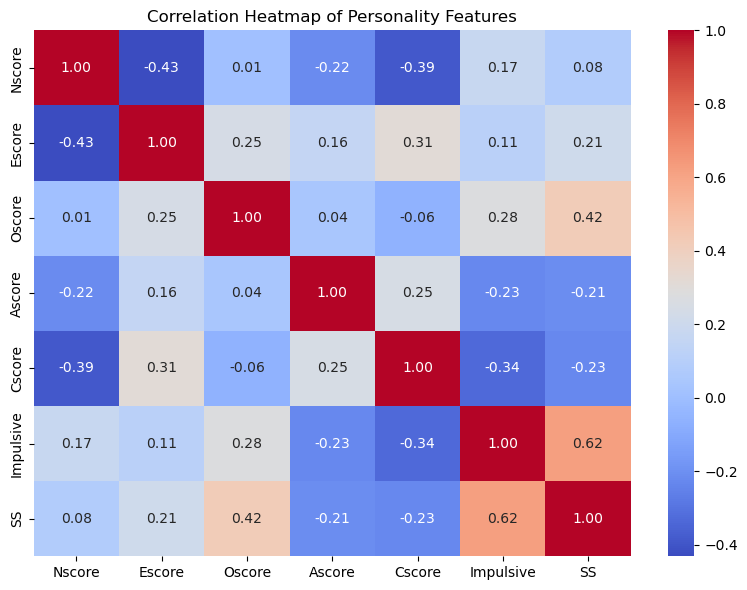

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[personality].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Personality Features')
plt.tight_layout()
plt.show()

Country
-0.57009     557
-0.46841       5
-0.28519     118
-0.09765      54
 0.21128      20
 0.24923      87
 0.96082    1044
Name: count, dtype: int64
Country_raw
0     557
1       5
2     118
3      54
4      20
5      87
6    1044
Name: count, dtype: int64


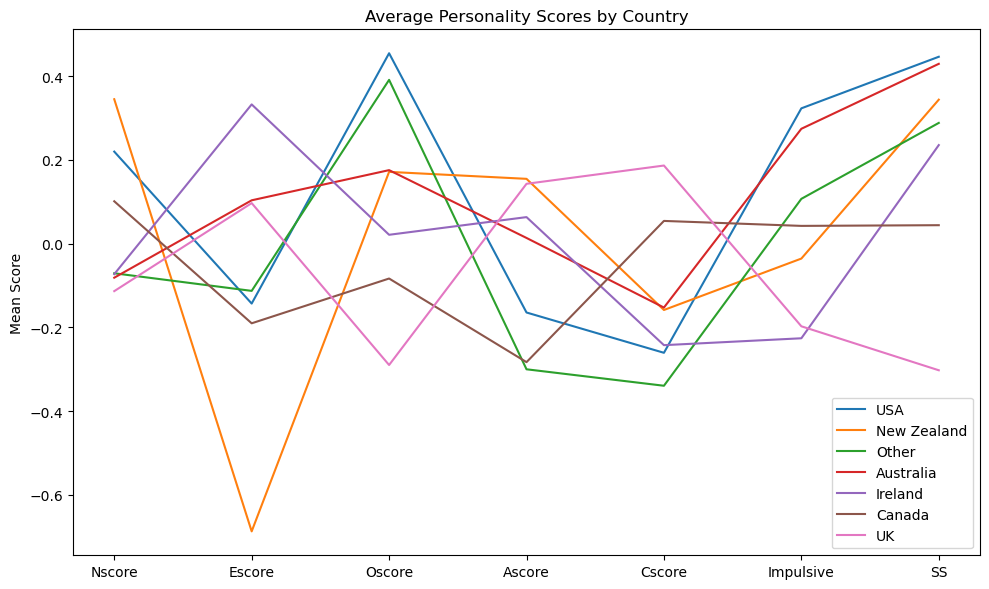

In [11]:
df_raw = pd.read_csv('group_20.csv')
print(df_raw['Country'].value_counts().sort_index())
print(df['Country_raw'].value_counts().sort_index())
country_names = {0: 'USA', 1: 'New Zealand', 2: 'Other', 
                 3: 'Australia', 4: 'Ireland', 5: 'Canada', 6: 'UK'}
plt.figure(figsize=(10,6))
for code, name in country_names.items():
    subset = df[df['Country_raw'] == code]
    means = subset[personality].mean()
    plt.plot(personality, means, label=name)

plt.title('Average Personality Scores by Country')
plt.ylabel('Mean Score')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# tree

In [12]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('group_20_1.csv')


In [13]:
X = df.drop(columns=['ID', 'Amyl', 'Country_raw', 'Ethnicity_raw'])
y = df['Amyl']
print(X.columns.tolist())
print(len(df))
print(y.value_counts().sort_index())
print((y.value_counts().sort_index() / len(y)).round(3))

['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
1885
Amyl
0    1305
1     210
2     370
Name: count, dtype: int64
Amyl
0    0.692
1    0.111
2    0.196
Name: count, dtype: float64


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=323, stratify=y
)

print(f"{X_train.shape}")
print(f"{X_test.shape}")
print(f"{y_train.value_counts().sort_index()}")

(1508, 12)
(377, 12)
Amyl
0    1044
1     168
2     296
Name: count, dtype: int64


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=323)

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=323),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters", rf_grid.best_params_)
print(f"Best Macro F1: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Best Macro F1: 0.5307


              precision    recall  f1-score   support

  Never Used       0.82      0.77      0.80       261
  Decade Ago       0.29      0.40      0.34        42
      Recent       0.51      0.50      0.50        74

    accuracy                           0.68       377
   macro avg       0.54      0.56      0.55       377
weighted avg       0.70      0.68      0.69       377

Test Macro F1: 0.5467


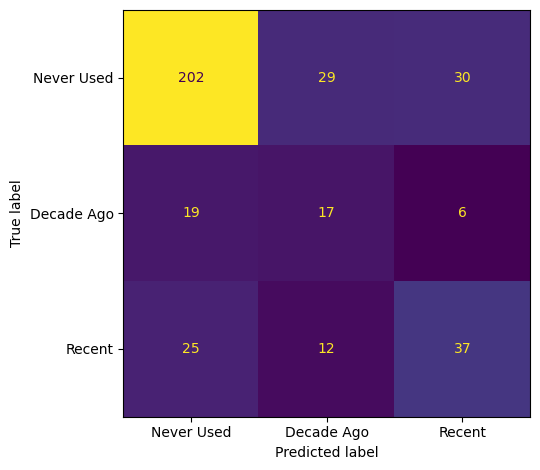

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

y_pred_rf = rf_grid.predict(X_test)

print(classification_report(y_test, y_pred_rf, 
      target_names=['Never Used', 'Decade Ago', 'Recent']))

macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
print(f"Test Macro F1: {macro_f1:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=323),
    dt_param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print(f"Best Macro F1 Macro F1: {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}
Best Macro F1 Macro F1: 0.4630


              precision    recall  f1-score   support

  Never Used       0.79      0.44      0.57       261
  Decade Ago       0.23      0.67      0.34        42
      Recent       0.36      0.51      0.42        74

    accuracy                           0.48       377
   macro avg       0.46      0.54      0.44       377
weighted avg       0.64      0.48      0.51       377

Test Macro F1: 0.4424


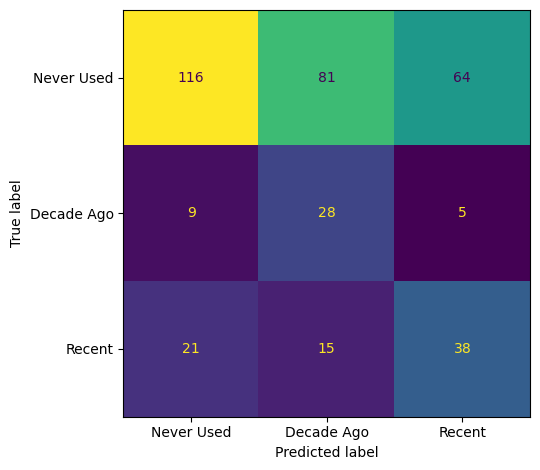

In [18]:
y_pred_dt = dt_grid.predict(X_test)

print(classification_report(y_test, y_pred_dt,
      target_names=['Never Used', 'Decade Ago', 'Recent']))

dt_macro_f1 = f1_score(y_test, y_pred_dt, average='macro')
print(f"Test Macro F1: {dt_macro_f1:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

In [20]:
# NN_v2

In [21]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [22]:
SEED = 323
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [23]:
df = pd.read_csv('group_20_1.csv')
feature_cols = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
                'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
                'Impulsive', 'SS']
X = df[feature_cols].values
y = df['Amyl'].values


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
y_train_s1 = (y_train != 0).astype(int)
y_test_s1  = (y_test  != 0).astype(int)
print(X_train.shape)
print(np.bincount(y_train_s1))
print(np.bincount(y_test_s1))

(1508, 12)
[1044  464]
[261 116]


In [25]:
class BinaryNet(nn.Module):
    def __init__(self, input_dim):
        super(BinaryNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

In [26]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_s1_t = torch.tensor(y_train_s1, dtype=torch.float32).unsqueeze(1)
y_test_s1_t  = torch.tensor(y_test_s1,  dtype=torch.float32).unsqueeze(1)
train_ds = TensorDataset(X_train_t, y_train_s1_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
torch.manual_seed(SEED)
model_s1 = BinaryNet(input_dim=12)
pos_weight = torch.tensor([1044 / 464])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_s1.parameters(), lr=0.001)
EPOCHS = 200

for epoch in range(EPOCHS):
    model_s1.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_s1(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

Epoch 10/200  Loss: 0.8526
Epoch 20/200  Loss: 0.8242
Epoch 30/200  Loss: 0.8054
Epoch 40/200  Loss: 0.7789
Epoch 50/200  Loss: 0.7960
Epoch 60/200  Loss: 0.7916
Epoch 70/200  Loss: 0.7726
Epoch 80/200  Loss: 0.7649
Epoch 90/200  Loss: 0.7901
Epoch 100/200  Loss: 0.7875
Epoch 110/200  Loss: 0.7608
Epoch 120/200  Loss: 0.7511
Epoch 130/200  Loss: 0.7737
Epoch 140/200  Loss: 0.7404
Epoch 150/200  Loss: 0.7272
Epoch 160/200  Loss: 0.7159
Epoch 170/200  Loss: 0.7432
Epoch 180/200  Loss: 0.7104
Epoch 190/200  Loss: 0.6971
Epoch 200/200  Loss: 0.7337


In [27]:
model_s1.eval()
with torch.no_grad():
    preds_s1 = (model_s1(X_test_t).squeeze().numpy() >= 0.5).astype(int)

print(classification_report(y_test_s1, preds_s1, target_names=['CL0', 'Others']))
print(confusion_matrix(y_test_s1, preds_s1))

              precision    recall  f1-score   support

         CL0       0.78      0.90      0.83       261
      Others       0.65      0.41      0.51       116

    accuracy                           0.75       377
   macro avg       0.71      0.66      0.67       377
weighted avg       0.74      0.75      0.73       377

[[235  26]
 [ 68  48]]


In [28]:
mask_train_s2 = (y_train != 0)
X_train_s2 = X_train[mask_train_s2]
y_train_s2 = (y_train[mask_train_s2] - 1).clip(0)  
mask_test_s2 = (preds_s1 == 1)
X_test_s2 = X_test[mask_test_s2]
y_test_s2 = (y_test[mask_test_s2] - 1).clip(0)
print("Stage2 train set:", X_train_s2.shape, "distribution:", np.bincount(y_train_s2))
print("Stage2 test set:", X_test_s2.shape)

Stage2 train set: (464, 12) distribution: [168 296]
Stage2 test set: (74, 12)


In [29]:
X_train_s2_t = torch.tensor(X_train_s2, dtype=torch.float32)
X_test_s2_t  = torch.tensor(X_test_s2,  dtype=torch.float32)
y_train_s2_t = torch.tensor(y_train_s2, dtype=torch.float32).unsqueeze(1)
y_test_s2_t  = torch.tensor(y_test_s2,  dtype=torch.float32).unsqueeze(1)

train_ds_s2 = TensorDataset(X_train_s2_t, y_train_s2_t)
train_loader_s2 = DataLoader(train_ds_s2, batch_size=32, shuffle=True)

torch.manual_seed(SEED)
model_s2 = BinaryNet(input_dim=12)
pos_weight_s2 = torch.tensor([168 / 296])
criterion_s2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_s2)
optimizer_s2 = torch.optim.Adam(model_s2.parameters(), lr=0.001)

EPOCHS = 20
for epoch in range(EPOCHS):
    model_s2.train()
    total_loss = 0
    for X_batch, y_batch in train_loader_s2:
        optimizer_s2.zero_grad()
        loss = criterion_s2(model_s2(X_batch), y_batch)
        loss.backward()
        optimizer_s2.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader_s2):.4f}")

Epoch 10/20  Loss: 0.3803
Epoch 20/20  Loss: 0.3602


In [30]:
model_s2.eval()
with torch.no_grad():
    preds_s2 = (model_s2(X_test_s2_t).squeeze().numpy() >= 0.5).astype(int)

final_preds = np.zeros(len(y_test), dtype=int)
final_preds[np.where(mask_test_s2)[0]] = preds_s2 + 1

print(classification_report(y_test_s2, preds_s2, target_names=['CL1','CL2']))
print(classification_report(y_test, final_preds, target_names=['CL0','CL1','CL2']))
print("Confusion matrix\n", confusion_matrix(y_test, final_preds))

              precision    recall  f1-score   support

         CL1       0.71      0.71      0.71        41
         CL2       0.64      0.64      0.64        33

    accuracy                           0.68        74
   macro avg       0.67      0.67      0.67        74
weighted avg       0.68      0.68      0.68        74

              precision    recall  f1-score   support

         CL0       0.78      0.90      0.83       261
         CL1       0.29      0.29      0.29        42
         CL2       0.64      0.28      0.39        74

    accuracy                           0.71       377
   macro avg       0.57      0.49      0.51       377
weighted avg       0.69      0.71      0.69       377

Confusion matrix
 [[235  17   9]
 [ 27  12   3]
 [ 41  12  21]]


In [31]:
def get_preds(model, X):
    model.eval()
    with torch.no_grad():
        return (model(torch.tensor(X, dtype=torch.float32)
                      ).squeeze().numpy() >= 0.5).astype(int)

train_acc_s1 = (get_preds(model_s1, X_train) == (y_train != 0).astype(int)).mean()
test_acc_s1  = (preds_s1 == y_test_s1).mean()
print(f"Stage1 train set accuracy: {train_acc_s1:.3f}")
print(f"Stage1 test set accuracy: {test_acc_s1:.3f}")

train_acc_s2 = (get_preds(model_s2, X_train_s2) == y_train_s2).mean()
test_acc_s2  = (preds_s2 == y_test_s2).mean()
print(f"Stage2 train sey accuracy: {train_acc_s2:.3f}")
print(f"Stage2 test set accuracy: {test_acc_s2:.3f}")

Stage1 train set accuracy: 0.810
Stage1 test set accuracy: 0.751
Stage2 train sey accuracy: 0.752
Stage2 test set accuracy: 0.676


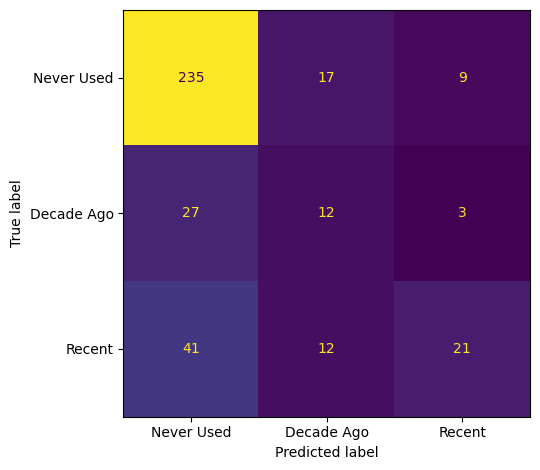

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, final_preds,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

In [33]:
# KNN

In [34]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))

              precision    recall  f1-score   support

  Never Used       0.73      0.92      0.81       261
  Decade Ago       0.36      0.12      0.18        42
      Recent       0.42      0.18      0.25        74

    accuracy                           0.69       377
   macro avg       0.50      0.41      0.41       377
weighted avg       0.62      0.69      0.63       377



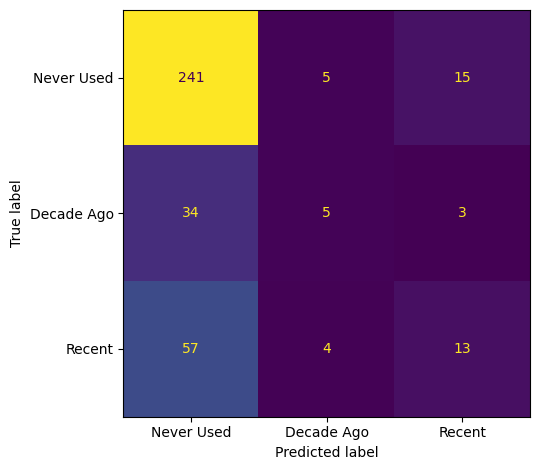

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.73      0.89      0.80       261
  Decade Ago       0.21      0.10      0.13        42
      Recent       0.45      0.24      0.32        74

    accuracy                           0.67       377
   macro avg       0.46      0.41      0.42       377
weighted avg       0.62      0.67      0.63       377



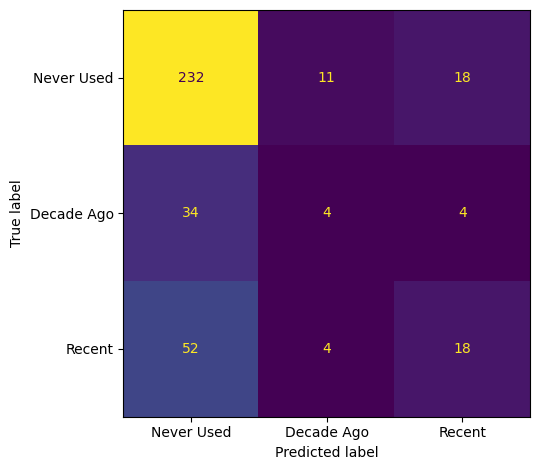

In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

  Never Used       0.74      0.92      0.82       261
  Decade Ago       0.29      0.10      0.14        42
      Recent       0.53      0.26      0.35        74

    accuracy                           0.70       377
   macro avg       0.52      0.43      0.44       377
weighted avg       0.65      0.70      0.65       377



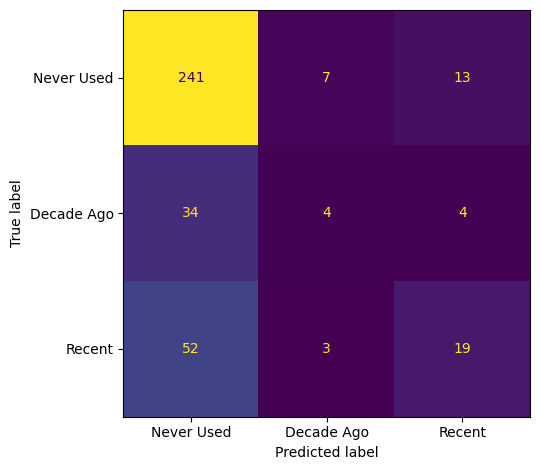

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.73      0.95      0.83       261
  Decade Ago       0.43      0.07      0.12        42
      Recent       0.53      0.22      0.31        74

    accuracy                           0.71       377
   macro avg       0.56      0.41      0.42       377
weighted avg       0.66      0.71      0.65       377



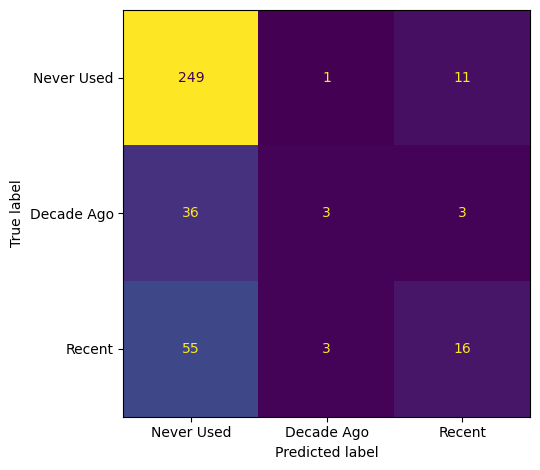

In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.73      0.95      0.83       261
  Decade Ago       0.43      0.07      0.12        42
      Recent       0.62      0.24      0.35        74

    accuracy                           0.72       377
   macro avg       0.59      0.42      0.43       377
weighted avg       0.68      0.72      0.65       377



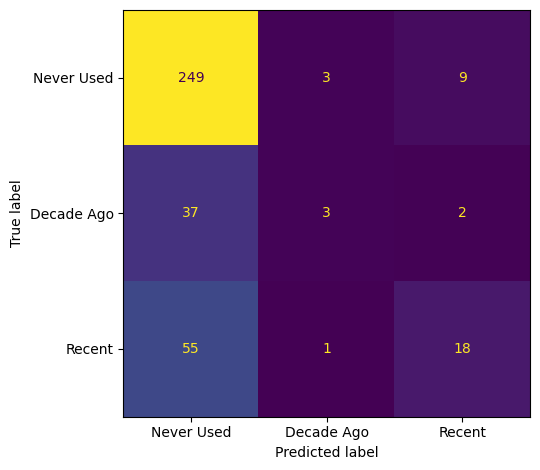

In [39]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.72      0.94      0.82       261
  Decade Ago       0.38      0.07      0.12        42
      Recent       0.52      0.19      0.28        74

    accuracy                           0.70       377
   macro avg       0.54      0.40      0.40       377
weighted avg       0.64      0.70      0.63       377



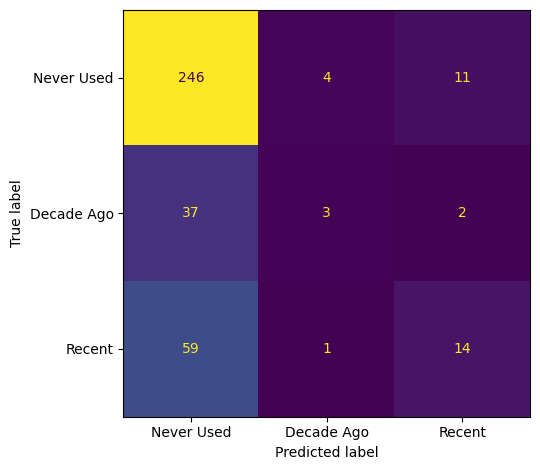

In [40]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

In [41]:
# SVM

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("group_20_1.csv")

target = "Amyl"

In [43]:
X=df.iloc[:,1:12]
# X.iloc[:,3:5]=df.iloc[:,14:16].copy()
X=X.values
y=df.iloc[:,13].values
n_features=X.shape[-1]
X

array([[ 0.52756593,  1.        , -0.05833058, ..., -0.91934136,
        -0.00628115, -0.23510842],
       [-0.1288537 ,  0.        ,  2.09319986, ...,  0.76336078,
        -0.14277542, -0.75297646],
       [ 0.52756593,  0.        , -0.05833058, ..., -1.62524491,
        -1.01690228, -1.45365042],
       ...,
       [-0.1288537 ,  1.        ,  0.48270524, ..., -1.77677285,
        -1.38844104,  0.54762541],
       [-1.12350447,  1.        , -0.6394053 , ..., -1.62524491,
        -2.57977769,  1.34669787],
       [-1.12350447,  0.        , -0.6394053 , ...,  1.1174608 ,
         0.41747077,  0.91587828]])

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [45]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
model = SVC(
    kernel="rbf",
    C=8.0,
    gamma=0.1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

SVC(C=8.0, class_weight='balanced', gamma=0.1)

In [47]:
preds = model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, preds))

Test accuracy: 0.6024734982332155


In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=['Never Used', 'Decade Ago', 'Recent']))

              precision    recall  f1-score   support

  Never Used       0.81      0.65      0.72       391
  Decade Ago       0.25      0.36      0.30        67
      Recent       0.40      0.58      0.48       108

    accuracy                           0.60       566
   macro avg       0.49      0.53      0.50       566
weighted avg       0.66      0.60      0.62       566



In [48]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, preds))

[[254  63  74]
 [ 24  24  19]
 [ 37   8  63]]


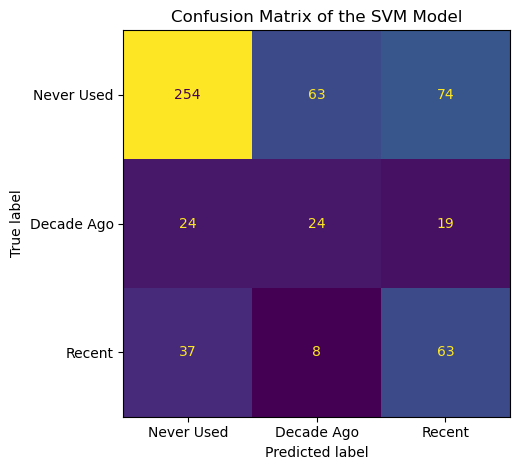

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.title('Confusion Matrix of the SVM Model')
plt.tight_layout()
plt.show()

In [51]:
# LR

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("group_20_1.csv")

target = "Amyl"

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [54]:
X=df.iloc[:,1:12]
# X.iloc[:,3:5]=df.iloc[:,14:16].copy()
X=X.values
y=df.iloc[:,13].values
n_features=X.shape[-1]
X

array([[ 0.52756593,  1.        , -0.05833058, ..., -0.91934136,
        -0.00628115, -0.23510842],
       [-0.1288537 ,  0.        ,  2.09319986, ...,  0.76336078,
        -0.14277542, -0.75297646],
       [ 0.52756593,  0.        , -0.05833058, ..., -1.62524491,
        -1.01690228, -1.45365042],
       ...,
       [-0.1288537 ,  1.        ,  0.48270524, ..., -1.77677285,
        -1.38844104,  0.54762541],
       [-1.12350447,  1.        , -0.6394053 , ..., -1.62524491,
        -2.57977769,  1.34669787],
       [-1.12350447,  0.        , -0.6394053 , ...,  1.1174608 ,
         0.41747077,  0.91587828]])

In [55]:
print(X.shape)
print(np.unique(y, return_counts=True))

(1885, 11)
(array([0, 1, 2], dtype=int64), array([1305,  210,  370], dtype=int64))


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

In [57]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
model = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500)

In [59]:
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)

print("Test accuracy:", acc)

Test accuracy: 0.5092838196286472


              precision    recall  f1-score   support

  Never Used       0.82      0.46      0.59       263
  Decade Ago       0.20      0.58      0.30        36
      Recent       0.40      0.63      0.49        78

    accuracy                           0.51       377
   macro avg       0.47      0.56      0.46       377
weighted avg       0.67      0.51      0.54       377



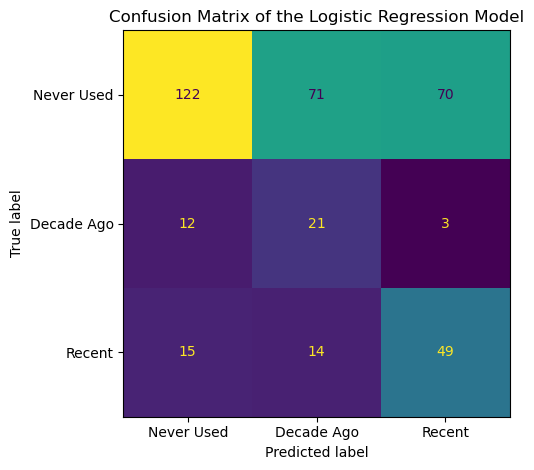

In [60]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, preds, target_names=['Never Used', 'Decade Ago', 'Recent']))

ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.title('Confusion Matrix of the Logistic Regression Model')
plt.tight_layout()
plt.show()